In [1]:
import os

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import preliz as pz
import pymc as pm
import xarray as xr
from scipy import interpolate, stats

In [2]:
az.style.use("arviz-darkgrid")

## Simple linear regression

### Linear bikes

<Axes: xlabel='temperature', ylabel='rented'>

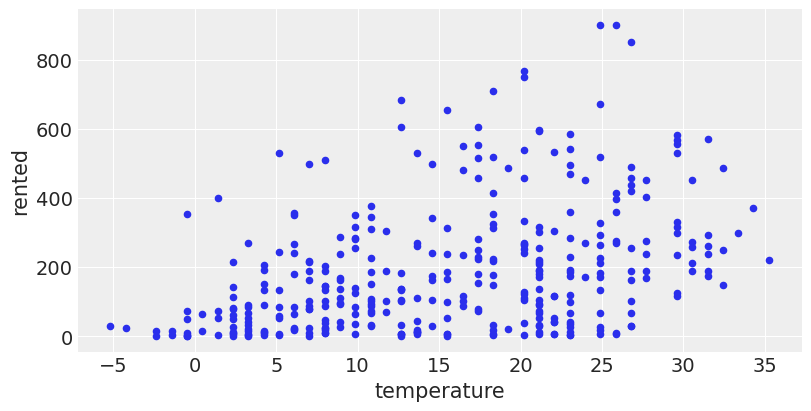

In [3]:
bikes = pd.read_csv("../data/bikes.csv")
bikes.plot(x="temperature", y="rented", figsize=(8, 4), kind="scatter")
# plt.savefig("../images/bbap/bap-03-bike.png")

In [4]:
path_bike = "../../book-prob-tmp/bap-04-bike.nc"
with pm.Model() as model_lb:
    α_b = pm.Normal("α", mu=0, sigma=100)
    β_b = pm.Normal("β", mu=0, sigma=10)
    ε_b = pm.HalfCauchy("ε", 10)
    μ_b = pm.Deterministic("μ", α_b + β_b * bikes.temperature)
    pm.Normal("y_pred", mu=μ_b, sigma=ε_b, observed=bikes.rented)
    if os.path.isfile(path_bike):
        idata_lb = az.from_netcdf(path_bike)
    else:
        idata_lb = pm.sample(2000, tune=1000)
        idata_lb.to_netcdf(path_bike)

### Interpreting the posterior mean

### Code 4.2

array([<Axes: title={'center': 'α'}>, <Axes: title={'center': 'β'}>,
       <Axes: title={'center': 'ε'}>], dtype=object)

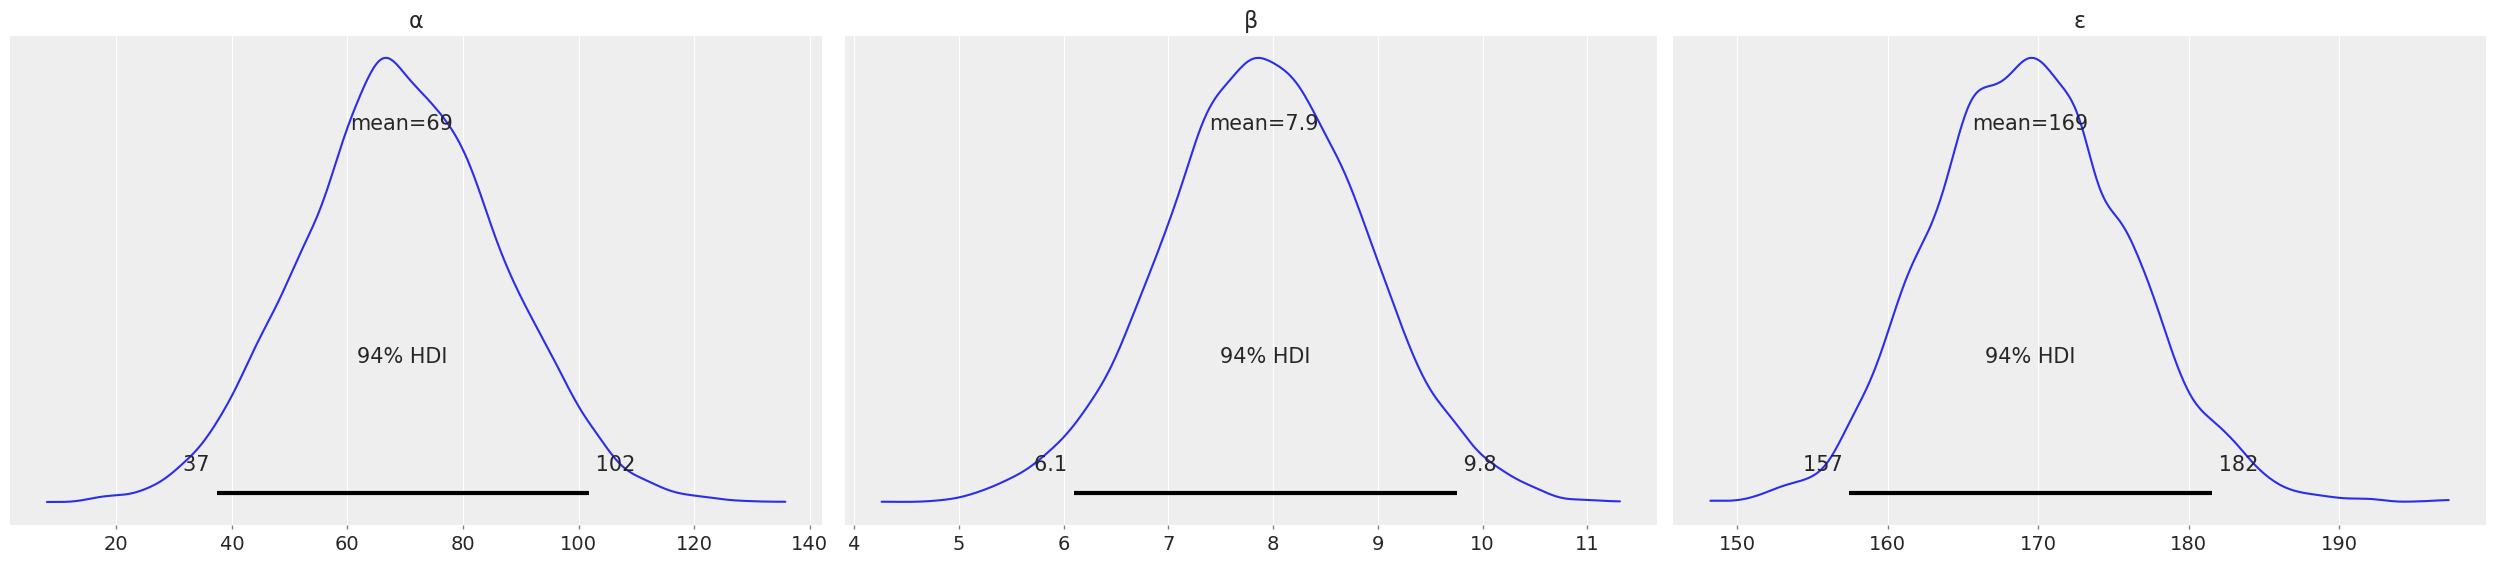

In [5]:
az.plot_posterior(idata_lb, var_names=["~μ"])
# plt.savefig("../images/bbap/bap-03-bike-post.png")

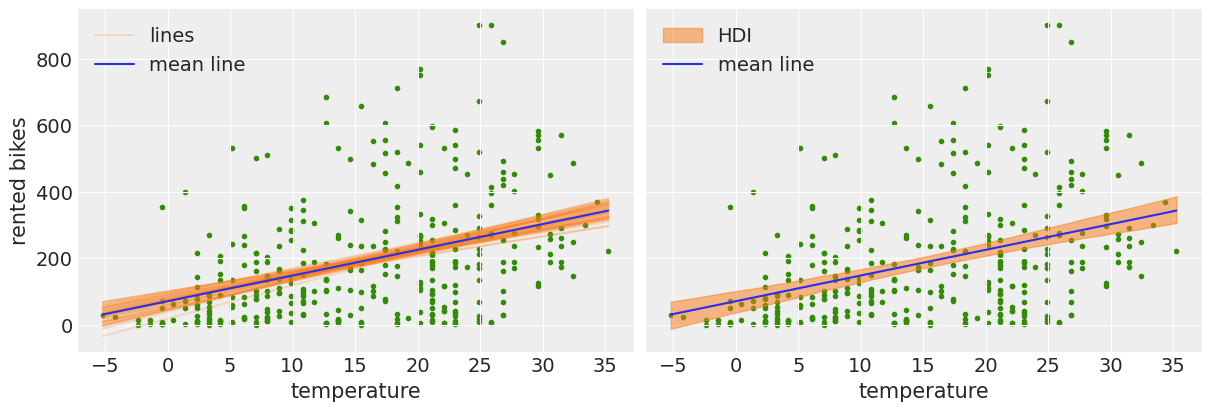

In [6]:
posterior = az.extract(idata_lb, num_samples=50)
x_plot = xr.DataArray(
    np.linspace(bikes.temperature.min(), bikes.temperature.max(), 50), dims="plot_id"
)
mean_line = posterior["α"].mean() + posterior["β"].mean() * x_plot
lines = posterior["α"] + posterior["β"] * x_plot
hdi_lines = az.hdi(idata_lb.posterior["μ"])

fig, axes0 = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
lines_ = axes0[0].plot(x_plot, lines.T, c="C1", alpha=0.2, label="lines")
plt.setp(lines_[1:], label="_")
axes0[0].set(ylabel="rented bikes")

idx_bike = np.argsort(bikes.temperature.values)
axes0[1].fill_between(
    bikes.temperature[idx_bike],
    hdi_lines["μ"][:, 0][idx_bike],
    hdi_lines["μ"][:, 1][idx_bike],
    color="C1",
    label="HDI",
    alpha=0.5,
)

for ax0 in axes0.flatten():
    ax0.plot(bikes.temperature, bikes.rented, "C2.", zorder=-3)
    ax0.plot(x_plot, mean_line, c="C0", label="mean line")
    ax0.set(xlabel="temperature")
    ax0.legend()

# plt.savefig("../images/bbap/bap-03-bike-lines.png")
plt.show()

### Interpreting the posterior predictions

### Code 4.4

In [7]:
pm.sample_posterior_predictive(
    idata_lb, model=model_lb, extend_inferencedata=True, random_seed=123
)

Sampling: [y_pred]


Output()

Inference data with groups:
	> posterior
	> posterior_predictive
	> sample_stats
	> observed_data

[Text(0.5, 0, 'temperature'), Text(0, 0.5, 'rented bikes')]

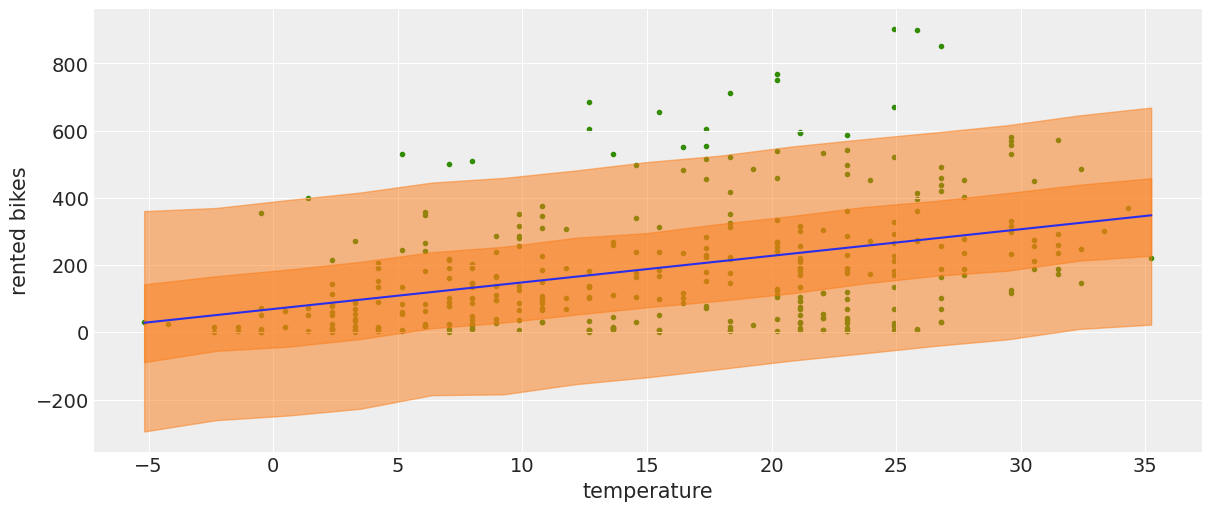

In [ ]:
mean_line_mu = idata_lb.posterior["μ"].mean(("chain", "draw"))
temperatures = np.random.normal(bikes.temperature.values, 0.01)
temper_idx = np.argsort(temperatures)
temper_x = np.linspace(temperatures.min(), temperatures.max(), 15)
y_pred_q = idata_lb.posterior_predictive["y_pred"].quantile(
    [0.03, 0.97, 0.25, 0.75], dim=["chain", "draw"]
)
y_hat_bounds = iter(
    [
        interpolate.PchipInterpolator(
            temperatures[temper_idx], y_pred_q[i][temper_idx]
        )(temper_x)
        for i in range(4)
    ]
)

_, ax = plt.subplots(figsize=(12, 5))
ax.plot(bikes.temperature, bikes.rented, "C2.", zorder=-3)
ax.plot(bikes.temperature[temper_idx], mean_line_mu[temper_idx], c="C0")

for lb, ub in zip(y_hat_bounds, y_hat_bounds):
    ax.fill_between(temper_x, lb, ub, color="C1", alpha=0.5)

ax.set(xlabel="temperature", ylabel="rented bikes")
# plt.savefig("../images/bbap/bap-03-bike-pred.png")

## Counting bikes

### Figure 4.6

In [9]:
path_bike_neg = "../../book-prob-tmp/bap-04-bike-neg.nc"
with pm.Model() as model_neg:
    α_n = pm.Normal("α", mu=0, sigma=1)
    β_n = pm.Normal("β", mu=0, sigma=10)
    σ_n = pm.HalfNormal("σ", 10)
    μ_n = pm.Deterministic("μ", pm.math.exp(α_n + β_n * bikes.temperature))
    pm.NegativeBinomial("y_pred", mu=μ_n, alpha=σ_n, observed=bikes.rented)
    if os.path.isfile(path_bike_neg):
        idata_neg = az.from_netcdf(path_bike_neg)
    else:
        idata_neg = pm.sample(random_seed=123)
        idata_neg.extend(pm.sample_posterior_predictive(idata_neg, random_seed=123))
        idata_neg.to_netcdf(path_bike_neg)

array([[<Axes: title={'center': 'α'}>, <Axes: title={'center': 'α'}>],
       [<Axes: title={'center': 'β'}>, <Axes: title={'center': 'β'}>],
       [<Axes: title={'center': 'σ'}>, <Axes: title={'center': 'σ'}>]],
      dtype=object)

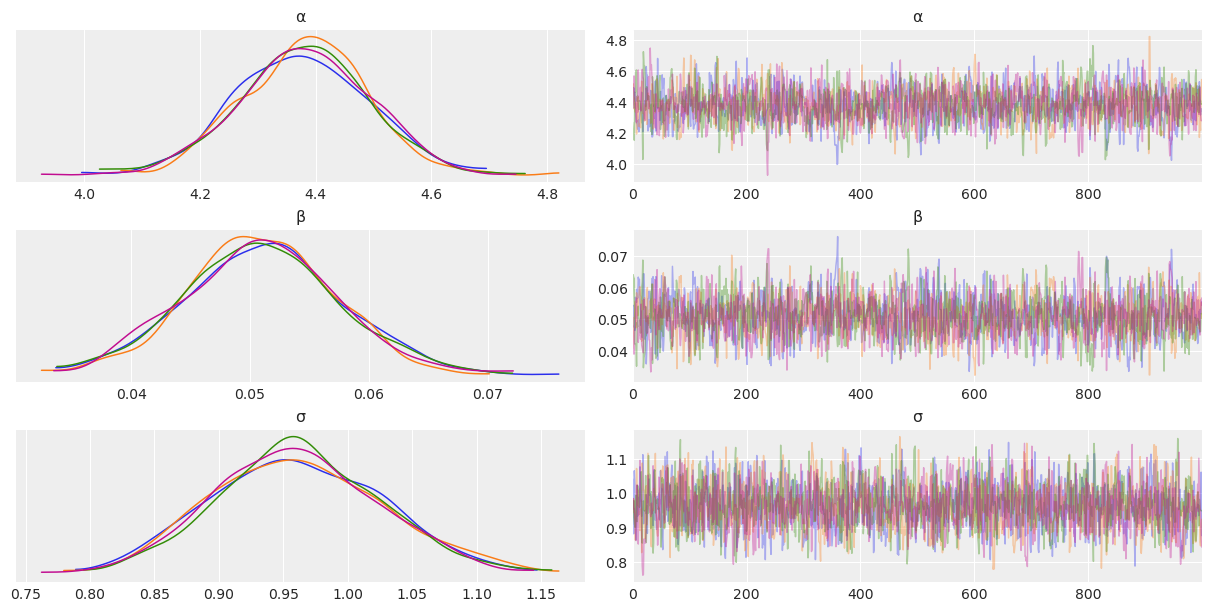

In [10]:
az.plot_trace(idata_neg, var_names=["~μ"], compact=False)

[Text(0.5, 0, 'temperature'), Text(0, 0.5, 'rented bikes')]

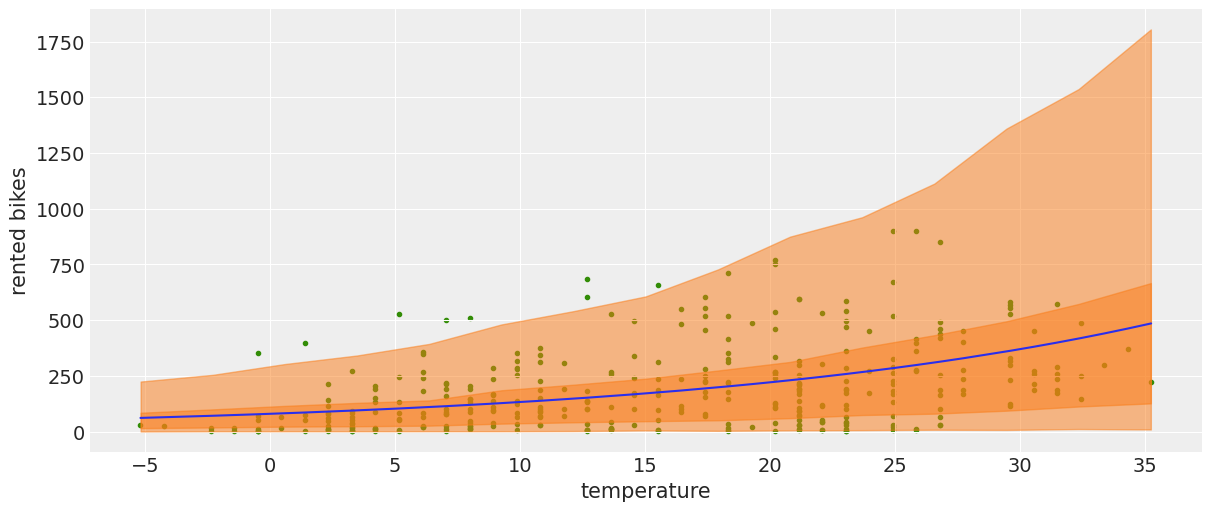

In [ ]:
mean_line_neg = idata_neg.posterior["μ"].mean(("chain", "draw"))
temperatures_neg = np.random.normal(bikes.temperature.values, 0.01)
idx_neg = np.argsort(temperatures_neg)
x_neg = np.linspace(temperatures_neg.min(), temperatures_neg.max(), 15)
y_pred_q_neg = idata_neg.posterior_predictive["y_pred"].quantile(
    [0.03, 0.97, 0.25, 0.75], dim=["chain", "draw"]
)
y_hat_bounds_neg = iter(
    [
        interpolate.PchipInterpolator(
            temperatures_neg[idx_neg], y_pred_q_neg[i][idx_neg]
        )(x_neg)
        for i in range(4)
    ]
)

_, ax_neg = plt.subplots(figsize=(12, 5))
ax_neg.plot(bikes.temperature, bikes.rented, "C2.", zorder=-3)
ax_neg.plot(bikes.temperature[idx_neg], mean_line_neg[idx_neg], c="C0")

for lb_neg, ub_neg in zip(y_hat_bounds_neg, y_hat_bounds_neg):
    ax_neg.fill_between(x_neg, lb_neg, ub_neg, color="C1", alpha=0.5)

ax_neg.set(xlabel="temperature", ylabel="rented bikes")
# plt.savefig("../images/bbap/bap-03-bike-pred2.png")

### Figure 4.7

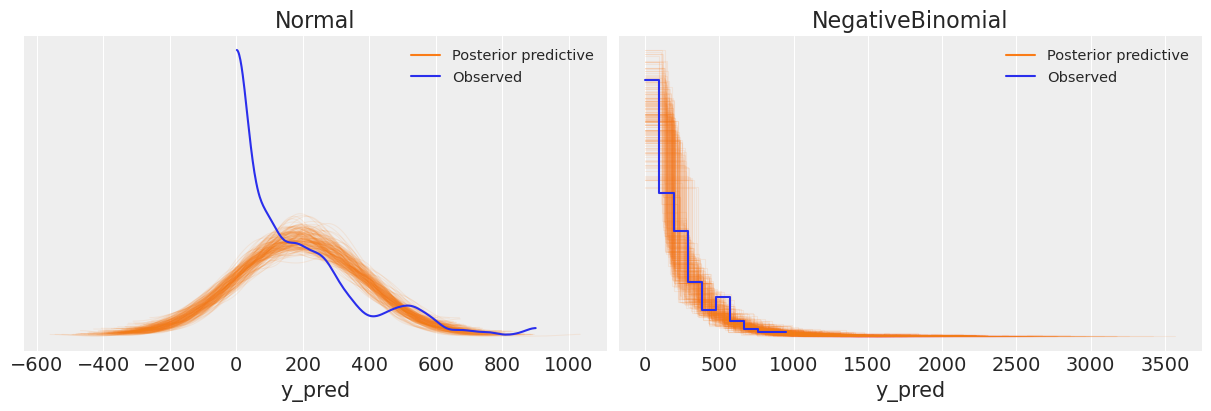

In [12]:
_, axes_b = plt.subplots(1, 2, figsize=(12, 4))
idatas = [idata_lb, idata_neg]
titles = ["Normal", "NegativeBinomial"]
for idata, axb, title in zip(idatas, axes_b, titles):
    az.plot_ppc(
        idata,
        num_pp_samples=200,
        alpha=0.1,
        colors=["C1", "C0", "C0"],
        mean=False,
        ax=axb,
    )
    axb.set(title=title)

# plt.savefig("../images/bbap/bap-03-bike-ppc.png")
plt.show()

## Robust linear regression

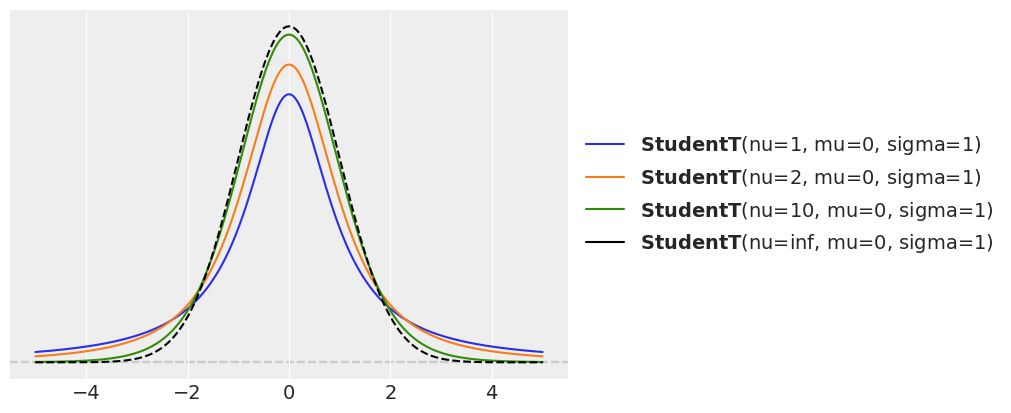

In [13]:
for nu in [1, 2, 10]:
    pz.StudentT(nu, 0, 1).plot_pdf(support=(-5, 5))

ax_t = pz.StudentT(np.inf, 0, 1).plot_pdf(support=(-5, 5), color="k")
ax_t.get_lines()[-1].set_linestyle("--")
# plt.savefig("../images/distrs/distr_t.png")
plt.show()

In [14]:
ans = pd.read_csv("../data/anscombe.csv")
ans.head()

,group,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


In [15]:
x_3 = ans.query("group == 'III'")["x"].to_numpy().flatten()
y_3 = ans.query("group == 'III'")["y"].to_numpy().flatten()
x_3 = x_3 - x_3.mean()

[Text(0.5, 0, 'y'), []]

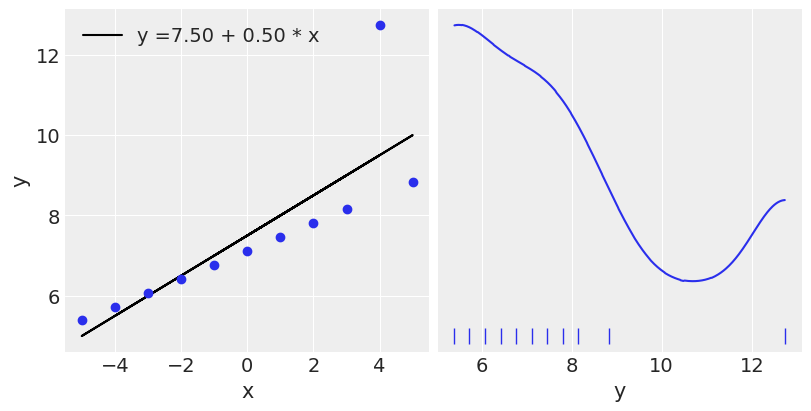

In [16]:
_, ax4 = plt.subplots(1, 2, figsize=(8, 4))
β_r, α_r = stats.linregress(x_3, y_3)[:2]
ax4[0].plot(x_3, α_r + β_r * x_3, "k", label=f"y ={α_r:.2f} + {β_r:.2f} * x")
ax4[0].plot(x_3, y_3, "C0o")
ax4[0].set(xlabel="x", ylabel="y")
ax4[0].legend(loc=0)
az.plot_kde(y_3, ax=ax4[1], rug=True)
ax4[1].set(xlabel="y", yticks=[])

### Code 4.6

In [17]:
path_ans = "../../book-prob-tmp/bap-04-anscombe.nc"
with pm.Model() as model_t:
    α_ = pm.Normal("α", mu=y_3.mean(), sigma=1)
    β_ = pm.Normal("β", mu=0, sigma=1)
    ε_ = pm.HalfNormal("ϵ", 5)
    ν__ = pm.Exponential("ν_", 1 / 29)
    ν_ = pm.Deterministic("ν", ν__ + 1)
    μ_ = pm.Deterministic("μ", α_ + β_ * ans.x)
    y_pred_ = pm.StudentT("y_pred", mu=α_ + β_ * x_3, sigma=ε_, nu=ν_, observed=y_3)
    if os.path.isfile(path_ans):
        idata_t = az.from_netcdf(path_ans)
    else:
        idata_t = pm.sample(2000, random_seed=4951)
        idata_t.to_netcdf(path_ans)

array([[<Axes: title={'center': 'α'}>, <Axes: title={'center': 'α'}>],
       [<Axes: title={'center': 'β'}>, <Axes: title={'center': 'β'}>],
       [<Axes: title={'center': 'ϵ'}>, <Axes: title={'center': 'ϵ'}>],
       [<Axes: title={'center': 'ν_'}>, <Axes: title={'center': 'ν_'}>],
       [<Axes: title={'center': 'ν'}>, <Axes: title={'center': 'ν'}>]],
      dtype=object)

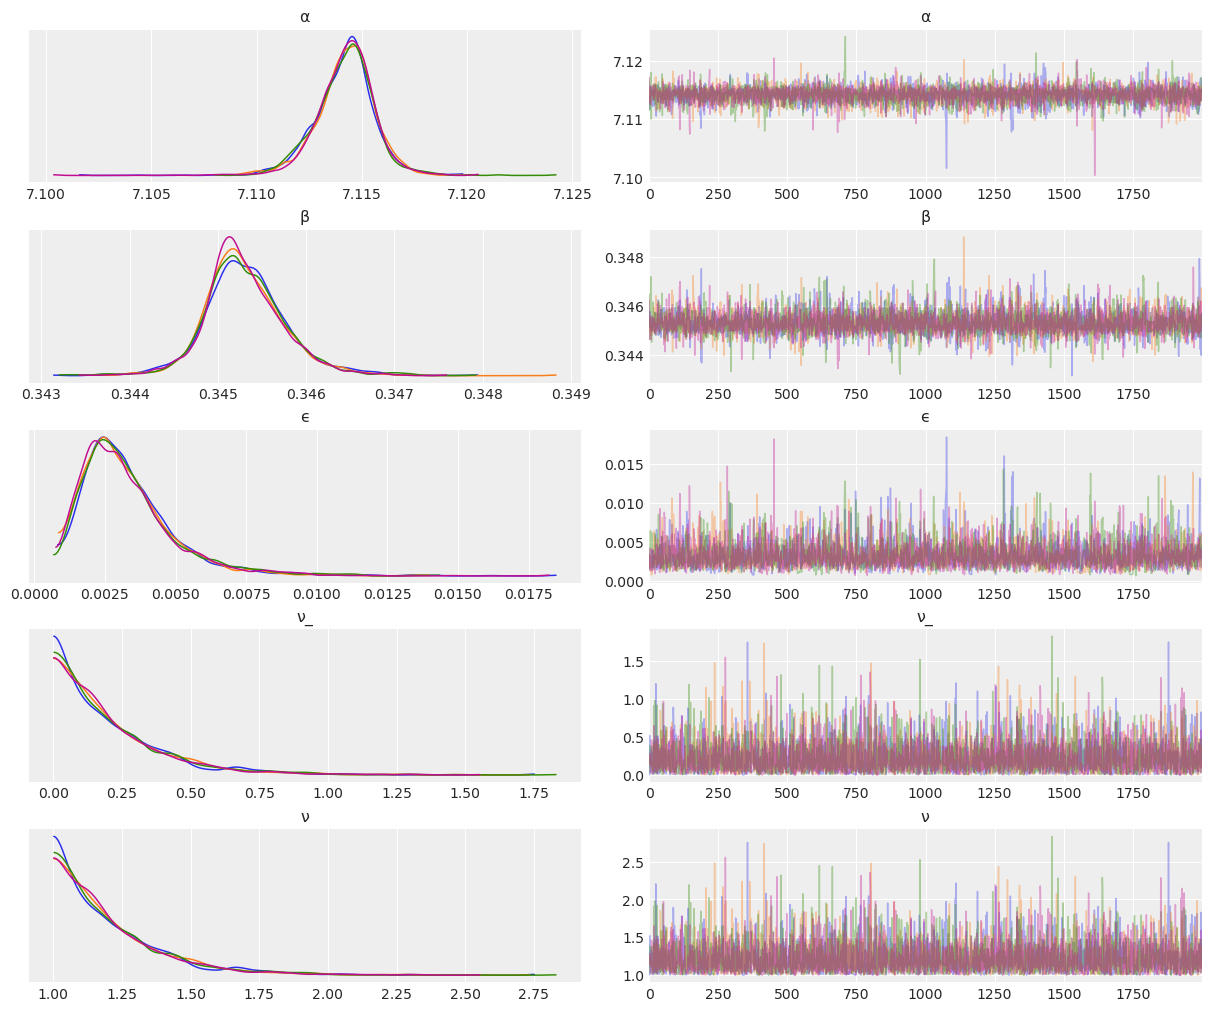

In [18]:
az.plot_trace(idata_t, var_names=["~μ"], compact=False)
# plt.savefig("../images/bbap/bap-04-anscombe-trace.png")

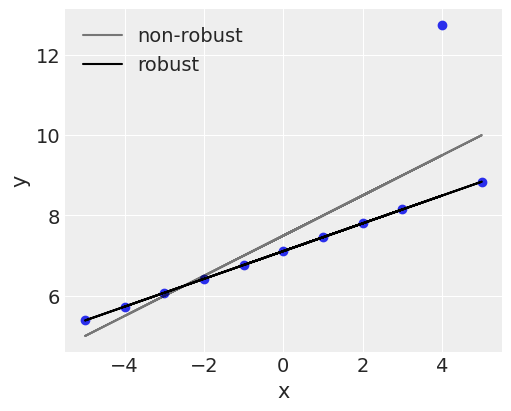

In [19]:
β_c_1, α_c_1 = stats.linregress(x_3, y_3)[:2]
α_m_1 = idata_t.posterior["α"].mean().to_numpy().flatten()
β_m_1 = idata_t.posterior["β"].mean().to_numpy().flatten()
_, ax5 = plt.subplots(figsize=(5, 4))
ax5.plot(x_3, y_3, "C0o")
ax5.plot(x_3, α_c_1 + β_c_1 * x_3, c="k", label="non-robust", alpha=0.5)
ax5.plot(x_3, α_m_1 + β_m_1 * x_3, c="k", label="robust")
ax5.set(xlabel="x", ylabel="y")
ax5.legend()

In [20]:
sum_t = az.summary(idata_t, var_names=["α", "β", "ϵ", "ν"], round_to=2, kind="stats")
# sum_t.to_csv("../python/bap-02-ans-trace.csv")
sum_t

,mean,sd,hdi_3%,hdi_97%
α,7.11,0.0,7.11,7.12
β,0.35,0.0,0.34,0.35
ϵ,0.00,0.0,0.00,0.01
ν,1.21,0.2,1.00,1.57


Sampling: [y_pred]


Output()

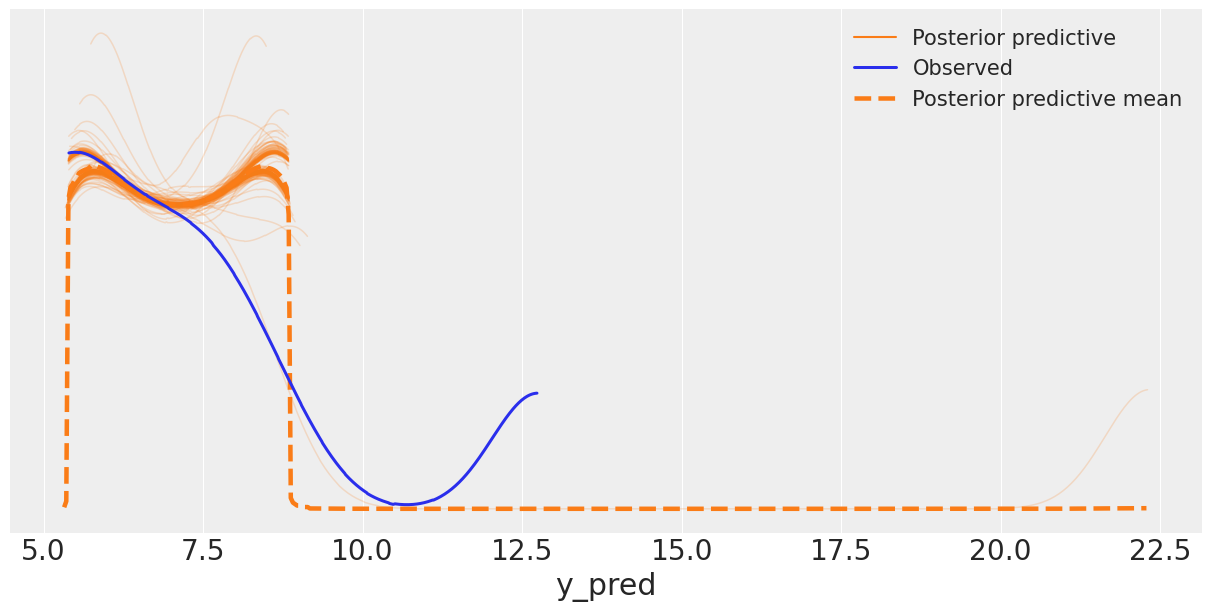

In [21]:
pm.sample_posterior_predictive(
    idata_t, model=model_t, random_seed=2, extend_inferencedata=True
)
ax_t2 = az.plot_ppc(
    idata_t, num_pp_samples=200, figsize=(12, 6), colors=["C1", "C0", "C1"]
)
# plt.savefig("../images/bbap/bap-04-anscombe-ppc.png")
plt.show()

## Multiple linear regression

In [22]:
path_mreg = "../../book-prob-tmp/bap-04-multireg.nc"

with pm.Model() as model_mlb:
    α_ml = pm.Normal("α", mu=0, sigma=1)
    β0_ml = pm.Normal("β0", mu=0, sigma=10)
    β1_ml = pm.Normal("β1", mu=0, sigma=10)
    σ_ml = pm.HalfNormal("σ", 10)
    μ_ml = pm.Deterministic(
        "μ", pm.math.exp(α_ml + β0_ml * bikes.temperature + β1_ml * bikes.hour)
    )
    _ = pm.NegativeBinomial("y_pred", mu=μ_ml, alpha=σ_ml, observed=bikes.rented)

    if os.path.isfile(path_mreg):
        idata_mlb = az.from_netcdf(path_mreg)
    else:
        idata_mlb = pm.sample(random_seed=123)
        idata_mlb.to_netcdf(path_mreg)

In [23]:
idata_neg.posterior["β0_scaled"] = idata_neg.posterior["β"] * bikes.temperature.std()
idata_mlb.posterior["β0_scaled"] = idata_mlb.posterior["β0"] * bikes.temperature.std()
idata_mlb.posterior["β1_scaled"] = idata_mlb.posterior["β1"] * bikes.hour.std()

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

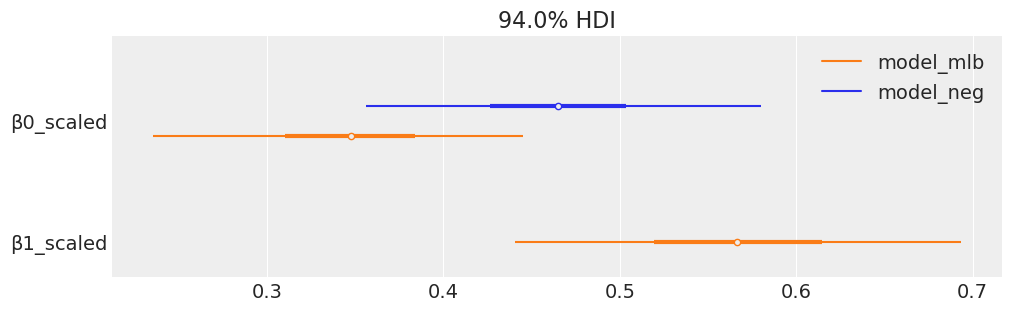

In [24]:
az.plot_forest(
    [idata_neg, idata_mlb],
    model_names=["model_neg", "model_mlb"],
    var_names=["β0_scaled", "β1_scaled"],
    figsize=(10, 3),
    combined=True,
)
# plt.savefig("../images/bbap/bap-04-multireg-comp.png")

## Variable variance

### Code 4.9

In [25]:
babies = pd.read_csv("../data/babies.csv")
babies

,Month,Length
0,0,48.5
1,0,50.5
2,0,50.5
3,0,52.0
4,0,47.5
...,...,...
795,24,87.5
796,24,82.5
797,24,88.5
798,24,89.0


<Axes: xlabel='Month', ylabel='Length'>

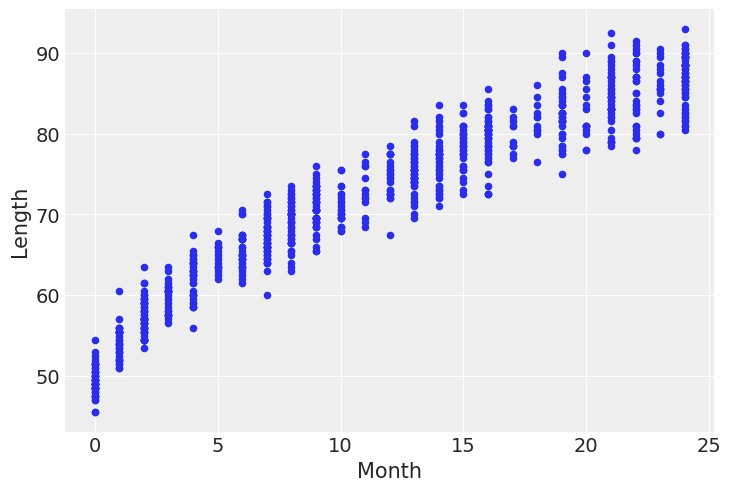

In [26]:
babies.plot.scatter("Month", "Length")
# plt.savefig("../images/bbap/bap-04-babies.png")

### Code 4.10

In [27]:
path_vv = "../../book-prob-tmp/bap-04-var-shared.nc"
with pm.Model() as model_vv:
    x_shared = pm.Data("x_shared", babies.Month.to_numpy())
    α_v = pm.Normal("α", sigma=10)
    β_v = pm.Normal("β", sigma=10)
    γ_v = pm.HalfNormal("γ", sigma=10)
    δ_v = pm.HalfNormal("δ", sigma=10)
    μ_v = pm.Deterministic("μ", α_v + β_v * x_shared**0.5)
    σ_v = pm.Deterministic("σ", γ_v + δ_v * x_shared)
    y_pred_vv = pm.Normal("y_pred", mu=μ_v, sigma=σ_v, observed=babies.Length)
    if os.path.isfile(path_vv):
        idata_vv = az.from_netcdf(path_vv)
    else:
        idata_vv = pm.sample(random_seed=123)
        idata_vv.to_netcdf(path_vv)

### Figure 4.13

Text(0, 0.5, '$\\bar σ$')

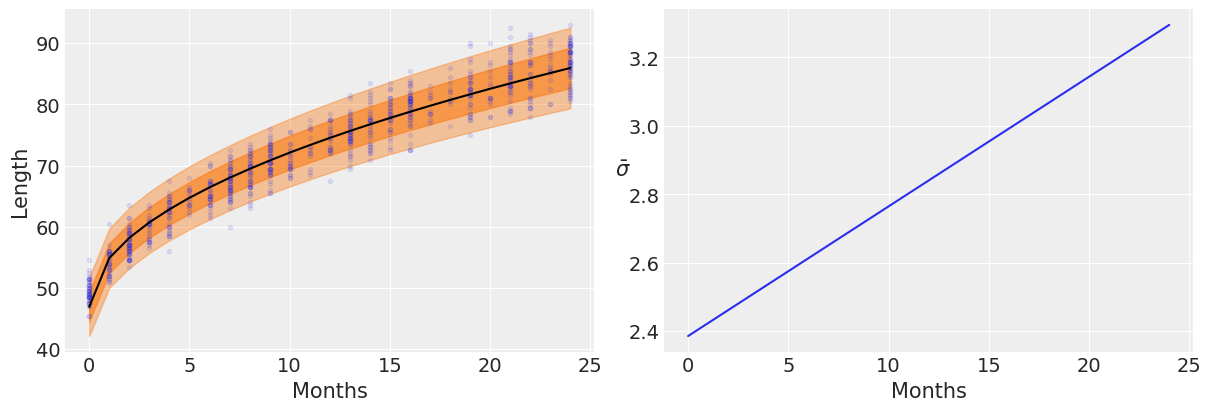

In [28]:
posterior_v = az.extract(idata_vv)
μ_m = posterior_v["μ"].mean("sample").to_numpy()
σ_m = posterior_v["σ"].mean("sample").to_numpy()

_, axes_v = plt.subplots(1, 2, figsize=(12, 4))
axes_v[0].plot(babies.Month, babies.Length, "C0.", alpha=0.1)
axes_v[0].plot(babies.Month, μ_m, c="k")
axes_v[0].fill_between(
    babies.Month, μ_m + 1 * σ_m, μ_m - 1 * σ_m, alpha=0.6, color="C1"
)
axes_v[0].fill_between(
    babies.Month, μ_m + 2 * σ_m, μ_m - 2 * σ_m, alpha=0.4, color="C1"
)
axes_v[0].set(xlabel="Months", ylabel="Length")

axes_v[1].plot(babies.Month, σ_m)
axes_v[1].set(xlabel="Months")
axes_v[1].set_ylabel(r"$\bar σ$", rotation=0)
# plt.savefig("../images/bbap/bap-04-babies-pred.png")

### Code 4.11

In [29]:
new_value = np.array([0.5])
with model_vv:
    pm.set_data({"x_shared": new_value.astype("int32")})
    ppc = pm.sample_posterior_predictive(idata_vv, random_seed=123)
    y_ppc_v = ppc.posterior_predictive["y_pred"].stack(sample=("chain", "draw"))


Sampling: [y_pred]


Output()

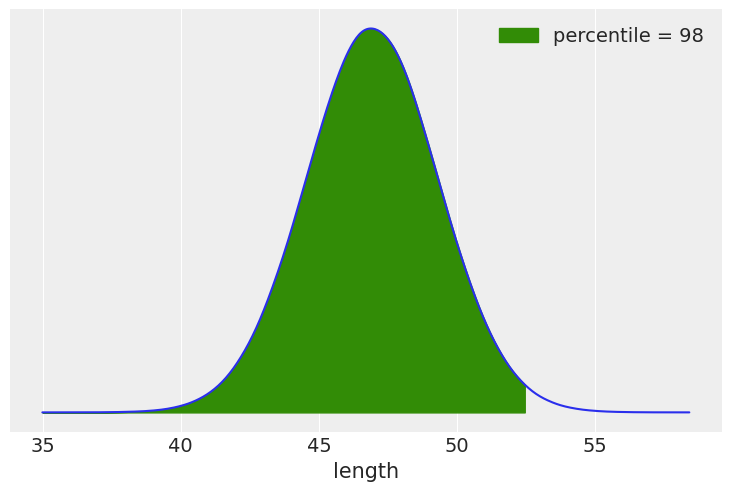

In [30]:
ref_v = 52.5
grid_v, pdf_v = az.stats.density_utils._kde_linear(y_ppc_v.values)
plt.plot(grid_v, pdf_v)
percentile_v = int((y_ppc_v <= ref_v).mean() * 100)
plt.fill_between(
    grid_v[grid_v < ref_v],
    pdf_v[grid_v < ref_v],
    label=f"percentile = {percentile_v:2d}",
    color="C2",
)
plt.xlabel("length")
plt.yticks([])
plt.legend()
# plt.savefig("../images/bbap/bap-04-babies-ppc.png")

## Hierarchical linear regression

### Figure 4.15

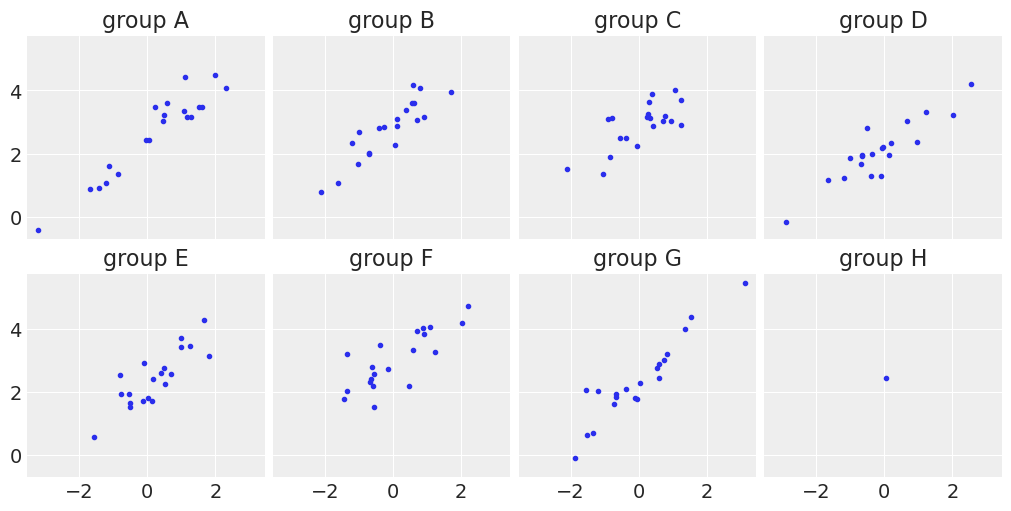

In [31]:
N = 20
groups = ["A", "B", "C", "D", "E", "F", "G", "H"]
M_g = len(groups)
idx_g = np.repeat(range(M_g - 1), N)
idx_g = np.append(idx_g, 7)
np.random.seed(314)
α_real_g = np.random.normal(2.5, 0.5, size=M_g)
β_real_g = np.random.beta(6, 1, size=M_g)
ϵ_real_g = np.random.normal(0, 0.5, size=len(idx_g))
y_m_g = np.zeros(len(idx_g))
x_m_g = np.random.normal(0, 1, len(idx_g))
y_m_g = α_real_g[idx_g] + β_real_g[idx_g] * x_m_g + ϵ_real_g

_, ax_g = plt.subplots(2, 4, figsize=(10, 5), sharex=True, sharey=True)
j_g, k_g = 0, N
ax_g = ax_g.flatten()
for i, g in enumerate(groups):
    ax_g[i].scatter(x_m_g[j_g:k_g], y_m_g[j_g:k_g], marker=".")
    ax_g[i].set_title(f"group {g}")
    j_g += N
    k_g += N
# plt.savefig("../images/bbap/bap-04-hier-groups.png")
plt.show()

### Code 4.12

In [32]:
path_gs = "../../book-prob-tmp/bap-04-hier-groups.nc"

coords = {"group": groups}
with pm.Model(coords=coords) as unpooled_model_gs:
    α_g = pm.Normal("α", mu=0, sigma=10, dims="group")
    β_g = pm.Normal("β", mu=0, sigma=10, dims="group")
    σ_g = pm.HalfNormal("σ", 5)
    _ = pm.Normal(
        "y_pred", mu=α_g[idx_g] + β_g[idx_g] * x_m_g, sigma=σ_g, observed=y_m_g
    )
    if os.path.isfile(path_gs):
        idata_up = az.from_netcdf(path_gs)
    else:
        idata_up = pm.sample(1000, tune=1000)
        idata_up.to_netcdf(path_gs)

### Figure 4.16

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

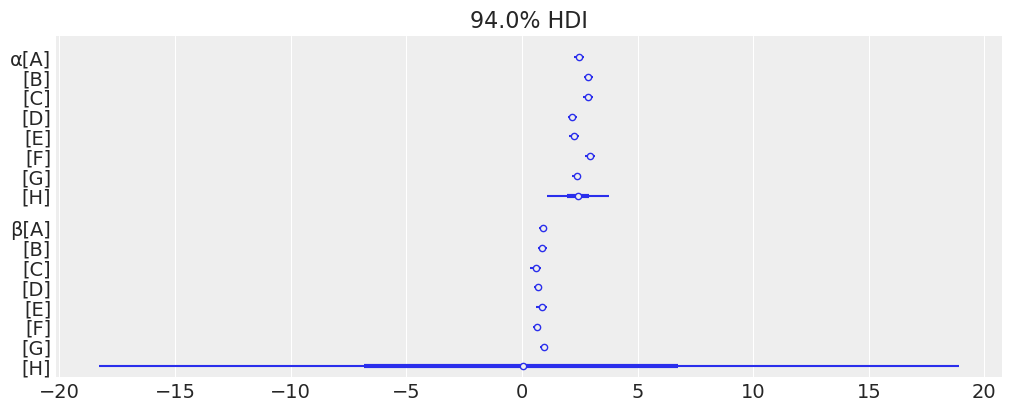

In [33]:
az.plot_forest(idata_up, var_names=["α", "β"], combined=True, figsize=(10, 4))

### Code 4.13

In [34]:
path_gs_h = "../../book-prob-tmp/bap-04-hier-groups-h.nc"

with pm.Model(coords=coords) as hierarchical_centered:
    # hyper-priors
    α_μ_h = pm.Normal("α_μ", mu=y_m_g.mean(), sigma=1)
    α_σ_h = pm.HalfNormal("α_σ", 5)
    β_μ_h = pm.Normal("β_μ", mu=0, sigma=1)
    β_σ_h = pm.HalfNormal("β_σ", sigma=5)
    # priors
    α_h = pm.Normal("α", mu=α_μ_h, sigma=α_σ_h, dims="group")
    β_h = pm.Normal("β", mu=β_μ_h, sigma=β_μ_h, dims="group")
    σ_h = pm.HalfNormal("σ", 5)
    _ = pm.Normal(
        "y_pred", mu=α_h[idx_g] + β_h[idx_g] * x_m_g, sigma=σ_h, observed=y_m_g
    )
    if os.path.isfile(path_gs_h):
        idata_cen = az.from_netcdf(path_gs_h)
    else:
        idata_cen = pm.sample(random_seed=123)
        idata_cen.to_netcdf(path_gs_h)

### Code 4.14

In [35]:
path_gs_hn = "../../book-prob-tmp/bap-04-hier-groups-hn.nc"

with pm.Model(coords=coords) as hierarchical_non_centered:
    # hyper-priors
    α_μ_hn = pm.Normal("α_μ", mu=y_m_g.mean(), sigma=1)
    α_σ_hn = pm.HalfNormal("α_σ", 5)
    β_μ_hn = pm.Normal("β_μ", mu=0, sigma=1)
    β_σ_hn = pm.HalfNormal("β_σ", sigma=5)
    # priors
    α_hn = pm.Normal("α", mu=α_μ_hn, sigma=α_σ_hn, dims="group")
    β_offset_hn = pm.Normal("β_offset", mu=0, sigma=1, dims="group")
    β_hn = pm.Deterministic("β", β_μ_hn + β_offset_hn * β_σ_hn, dims="group")
    σ_hn = pm.HalfNormal("σ", 5)
    _ = pm.Normal(
        "y_pred", mu=α_hn[idx_g] + β_hn[idx_g] * x_m_g, sigma=σ_hn, observed=y_m_g
    )

    if os.path.isfile(path_gs_hn):
        idata_ncent = az.from_netcdf(path_gs_hn)
    else:
        idata_ncent = pm.sample(random_seed=123, target_accept=0.85)
        idata_ncent.to_netcdf(path_gs_hn)

### Figure 4.17

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

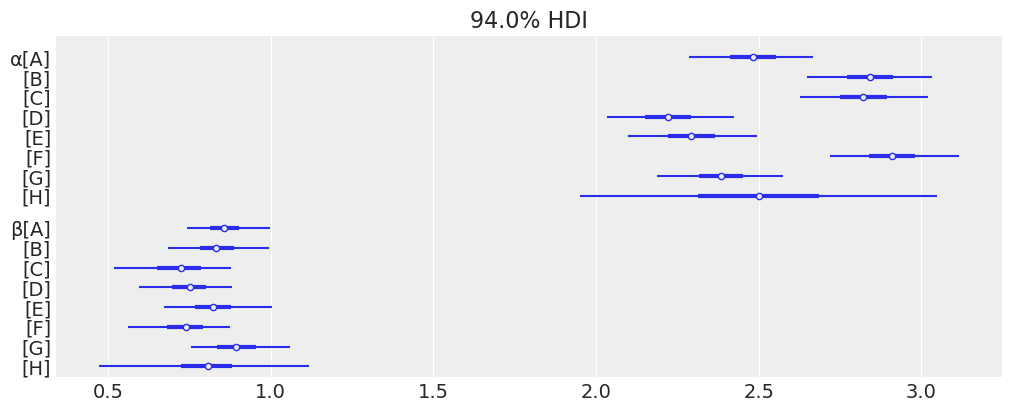

In [36]:
az.plot_forest(idata_ncent, var_names=["α", "β"], combined=True, figsize=(10, 4))
# plt.savefig("../images/bbap/bap-04-hier-comp.png")

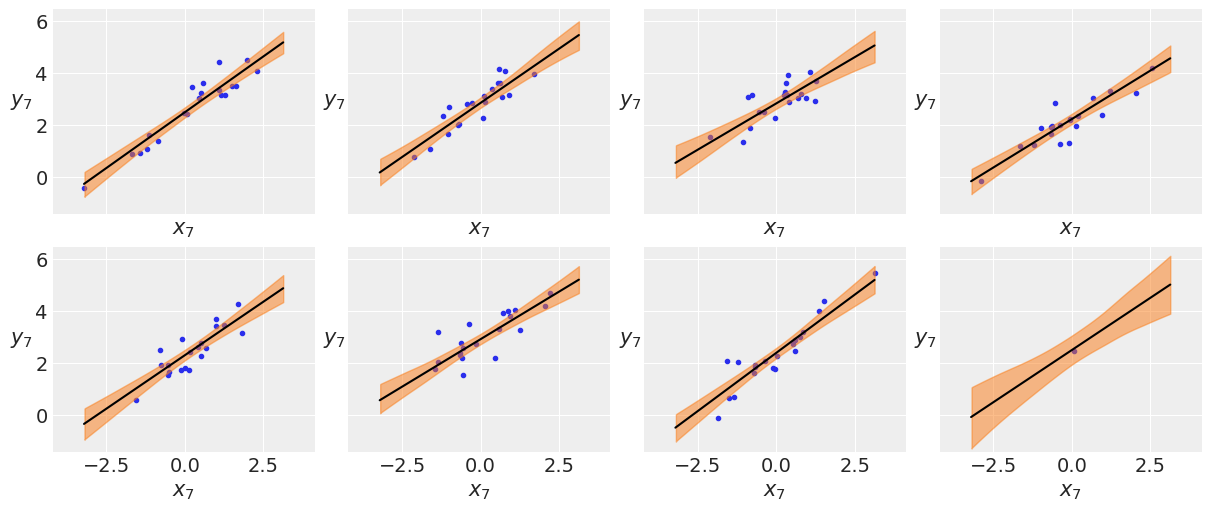

In [37]:
_, ax_gs = plt.subplots(2, 4, figsize=(12, 5), sharex=True, sharey=True)
ax_gs = np.ravel(ax_gs)
j_gs, k_gs = 0, N
x_range = np.linspace(x_m_g.min(), x_m_g.max(), 10)
trace_hdi_gs = az.hdi(idata_ncent)
posterior_gs = idata_ncent.posterior


for ind_gs, g_gs in enumerate(groups):
    ax_gs[ind_gs].scatter(x_m_g[j_gs:k_gs], y_m_g[j_gs:k_gs], marker=".")
    ax_gs[ind_gs].set_xlabel(f"$x_{i}$")
    ax_gs[ind_gs].set_ylabel(f"$y_{i}$", labelpad=10, rotation=0)
    αs = posterior_gs["α"].sel(group=g_gs)
    βs = posterior_gs["β"].sel(group=g_gs)
    α_mm = αs.mean(("chain", "draw")).item()
    β_mm = βs.mean(("chain", "draw")).item()
    ax_gs[ind_gs].plot(x_range, α_mm + β_mm * x_range, c="k")
    az.plot_hdi(x_range, αs + βs * xr.DataArray(x_range).transpose(), ax=ax_gs[ind_gs])
    plt.xlim(x_m_g.min() - 1, x_m_g.max() + 1)
    plt.ylim(y_m_g.min() - 1, y_m_g.max() + 1)
    j_gs += N
    k_gs += N

# plt.savefig("../images/bbap/bap-04-hier-fit.png")
plt.show()